# 01. EDA и приоритизация гипотез

## Содержание
1. [Загрузка данных](#загрузка-данных)
2. [EDA экономических данных](#eda-экономических-данных)
3. [Приоритизация гипотез (ICE/RICE)](#приоритизация-гипотез-icerice)
4. [Сравнение методов](#сравнение-методов)
5. [Выводы](#выводы)

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Загрузка данных из модуля
import sys
sys.path.append('..')
from src.data_loader import load_economic_data, load_monitoring_data, load_results_data

# Загрузка
df_economic = load_economic_data()
df_monitoring = load_monitoring_data()
df_results = load_results_data()

print(f"economic_data: {len(df_economic)} строк")
print(f"monitoring: {len(df_monitoring)} строк")
print(f"results: {len(df_results)} строк")

economic_data: 26 строк
monitoring: 960 строк
results: 11042 строк


## EDA экономических данных

In [3]:
print("Статистика экономических данных\n")
print(f"{'Показатель':<30} {'Среднее':>12} {'Мин':>10} {'Макс':>10}")
print("-" * 65)

metrics = {
    'emails_sent': 'Писем в неделю',
    'open_rate': 'Open Rate',
    'ctr': 'CTR',
    'conversion_to_purchase': 'Конверсия клик→покупка',
    'avg_order_value': 'Средний чек',
    'revenue': 'Выручка в неделю'
}

for col, label in metrics.items():
    mean_val = df_economic[col].mean()
    min_val = df_economic[col].min()
    max_val = df_economic[col].max()
    
    if col in ['open_rate', 'ctr', 'conversion_to_purchase']:
        print(f"{label:<30} {mean_val:>11.2%} {min_val:>9.2%} {max_val:>9.2%}")
    else:
        print(f"{label:<30} {mean_val:>12,.0f} {min_val:>10,.0f} {max_val:>10,.0f}")

Статистика экономических данных

Показатель                          Среднее        Мин       Макс
-----------------------------------------------------------------
Писем в неделю                       48,970     40,062     57,389
Open Rate                           24.69%    18.43%    31.90%
CTR                                  7.66%     6.82%     8.73%
Конверсия клик→покупка              15.35%    11.16%    19.93%
Средний чек                           3,581      2,799      4,197
Выручка в неделю                    500,056    263,198    794,485


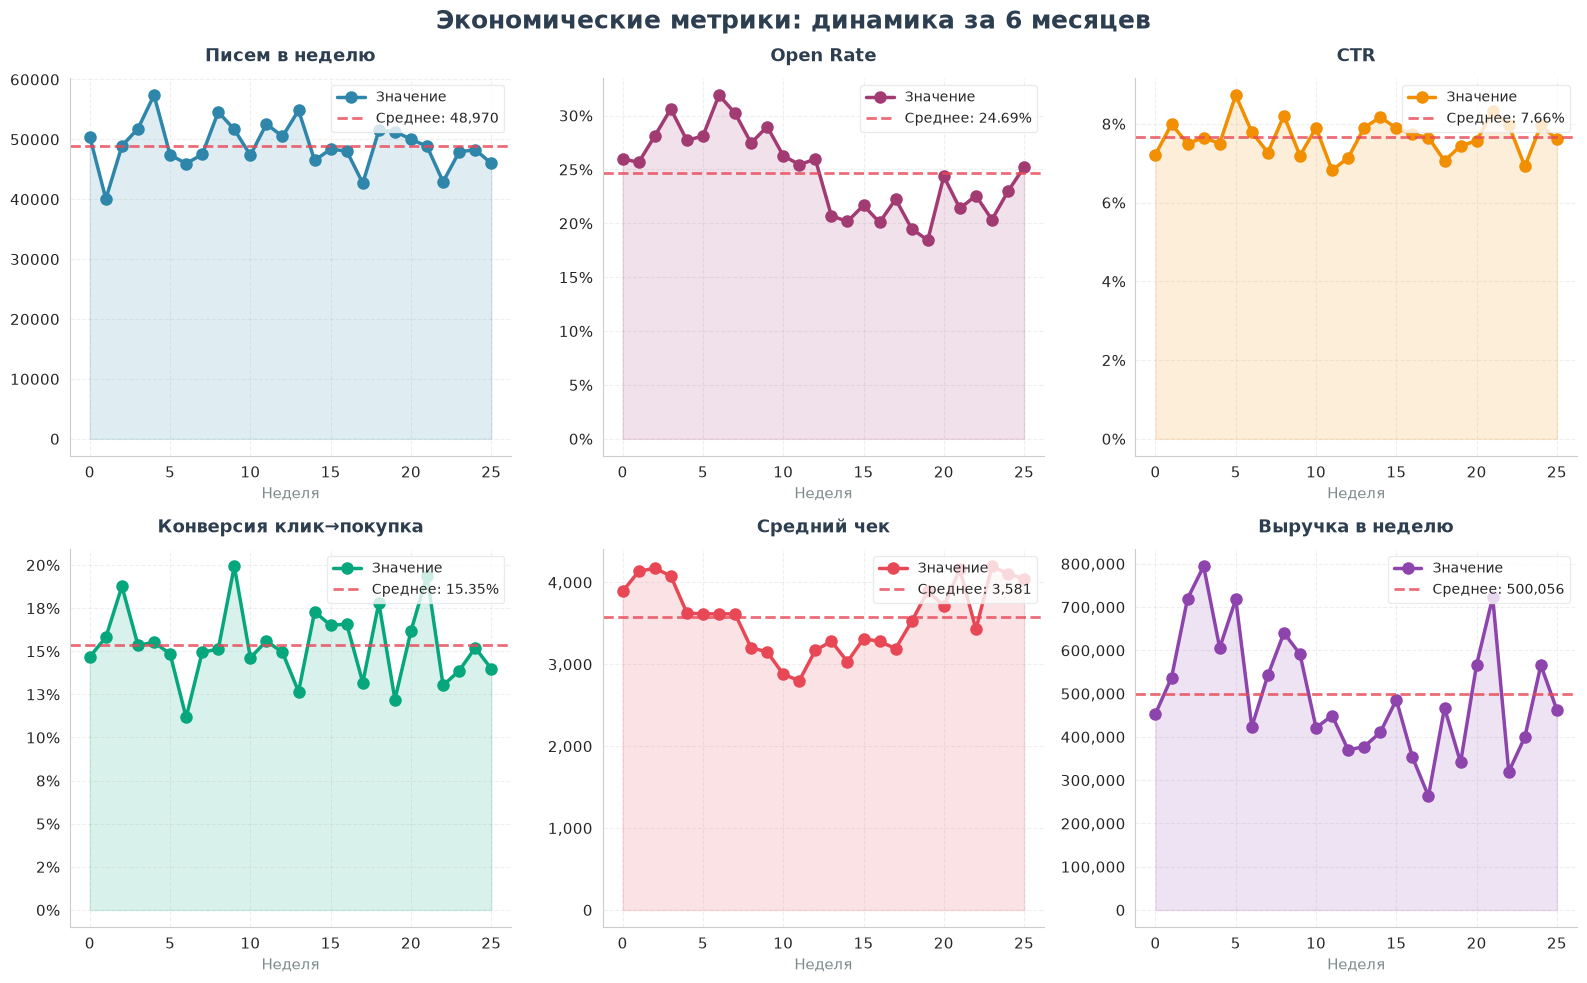

In [4]:
# Визуализация ключевых метрик
# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("Set2")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Цветовая палитра для графиков
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D', '#E84855', '#8E44AD']

for idx, (col, label) in enumerate(metrics.items()):
    ax = axes[idx]
    
    # Градиентный график с областями
    ax.fill_between(df_economic.index, df_economic[col], alpha=0.15, color=colors[idx])
    ax.plot(df_economic.index, df_economic[col], 
            marker='o', linewidth=2.5, markersize=8, 
            color=colors[idx], label='Значение')
    
    # Средняя линия
    mean_val = df_economic[col].mean()
    ax.axhline(mean_val, color='#E84855', linestyle='--', alpha=0.8, linewidth=2, label=f'Среднее: {mean_val:.2%}' if col in ['open_rate', 'ctr', 'conversion_to_purchase'] else f'Среднее: {mean_val:,.0f}')
    
    # Оформление
    ax.set_title(label, fontsize=13, fontweight='bold', color='#2C3E50', pad=12)
    ax.set_xlabel('Неделя', fontsize=11, color='#7F8C8D')
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#E5E7EB', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Форматирование оси Y
    if col in ['open_rate', 'ctr', 'conversion_to_purchase']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    elif col in ['revenue', 'avg_order_value']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:,.0f}'))

plt.suptitle('Экономические метрики: динамика за 6 месяцев', 
             fontsize=18, fontweight='bold', color='#2C3E50')
plt.tight_layout()
plt.show()

### Выводы по EDA

1. **CTR (ключевая метрика):**
   - Среднее: **7.66%**
   - Диапазон: 6.82% - 8.73%
   - Стабильность: вариация умеренная

2. **Open Rate:**
   - Среднее: 24.69%
   - Высокая вариативность (18.43% - 31.90%)

3. **Выручка:**
   - Среднее: 500,056 руб/неделю
   - Сильная сезонность

4. **Средний чек:**
   - Среднее: 3,581 руб
   - Стабильный показатель

## Приоритизация гипотез (ICE/RICE)

In [5]:
# Данные от 3 экспертов
experts = [
    {'impact': [5,7,6,3,8], 'reach': [7,6,5,4,3], 'confidence': [5,5,5,4,6], 'ease': [7,3,5,6,4]},
    {'impact': [3,9,4,1,9], 'reach': [8,7,6,4,2], 'confidence': [3,7,3,3,8], 'ease': [9,2,5,8,3]},
    {'impact': [4,8,5,2,9], 'reach': [8,5,7,4,1], 'confidence': [4,6,4,5,7], 'ease': [8,2,5,7,3]}
]

# Медианные оценки
df_hypotheses = pd.DataFrame({
    'id': range(1, 6),
    'hypothesis': [
        'Яркие заголовки',
        'Улучшение мобильной версии',
        'Персонализированные email-рассылки',
        'Интерактивные email-рассылки',
        'Персонализированные рекомендации'
    ],
    'description': [
        'Использовать яркие, кликбейтные заголовки в письмах',
        'Адаптировать дизайн писем под мобильные устройства',
        'Настраивать контент письма под историю пользователя',
        'Добавить интерактивные элементы (опросы, кнопки)',
        'Показывать товары на основе предыдущих покупок'
    ],
    'impact': np.median([e['impact'] for e in experts], axis=0).astype(int),
    'reach': np.median([e['reach'] for e in experts], axis=0).astype(int),
    'confidence': np.median([e['confidence'] for e in experts], axis=0).astype(int),
    'ease': np.median([e['ease'] for e in experts], axis=0).astype(int)
})

# Расчет ICE и RICE
df_hypotheses['ice'] = df_hypotheses['impact'] * df_hypotheses['confidence'] * df_hypotheses['ease']
df_hypotheses['effort'] = 11 - df_hypotheses['ease']
df_hypotheses['rice'] = (df_hypotheses['reach'] * df_hypotheses['impact'] * df_hypotheses['confidence'] / df_hypotheses['effort']).round(1)

df_hypotheses

,id,hypothesis,description,impact,reach,confidence,ease,ice,effort,rice
0,1,Яркие заголовки,"Использовать яркие, кликбейтные заголовки в пи...",4,8,4,8,128,3,42.7
1,2,Улучшение мобильной версии,Адаптировать дизайн писем под мобильные устрой...,8,6,6,2,96,9,32.0
2,3,Персонализированные email-рассылки,Настраивать контент письма под историю пользов...,5,6,4,5,100,6,20.0
3,4,Интерактивные email-рассылки,"Добавить интерактивные элементы (опросы, кнопки)",2,4,4,7,56,4,8.0
4,5,Персонализированные рекомендации,Показывать товары на основе предыдущих покупок,9,2,7,3,189,8,15.8


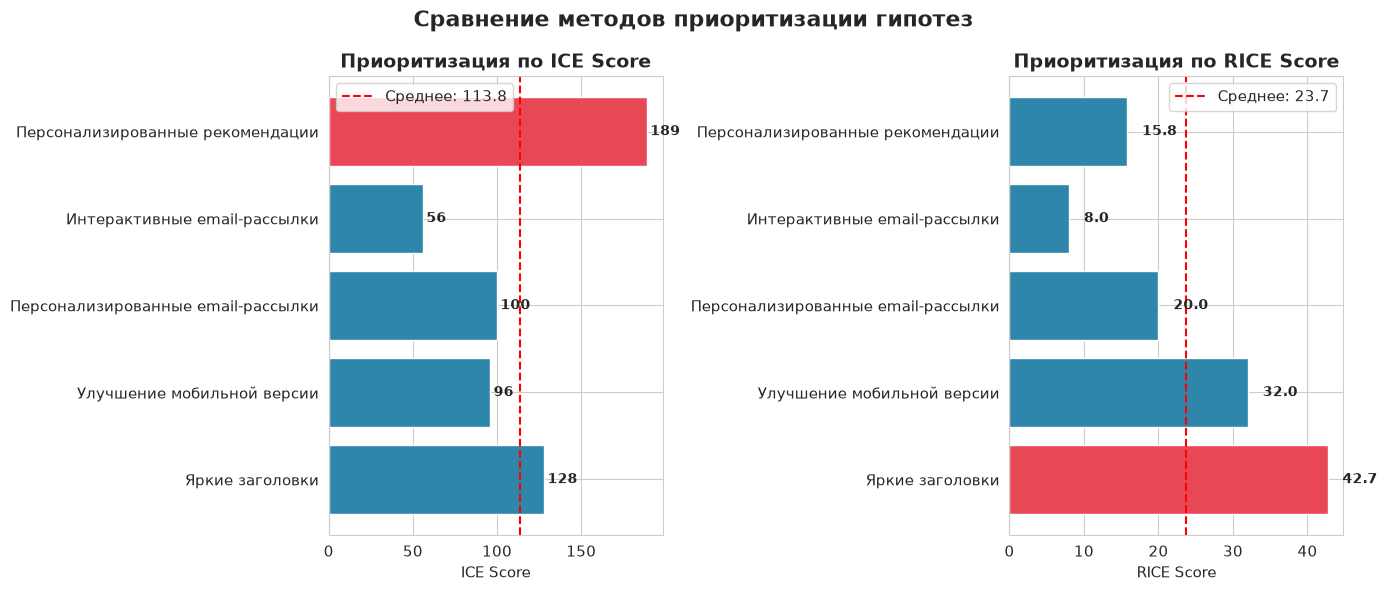

In [6]:
# Сравнение методов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: ICE
colors_ice = ['#E84855' if x == df_hypotheses['ice'].max() else '#2E86AB' for x in df_hypotheses['ice']]
bars1 = axes[0].barh(df_hypotheses['hypothesis'], df_hypotheses['ice'], color=colors_ice)
axes[0].set_title('Приоритизация по ICE Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ICE Score')
axes[0].axvline(df_hypotheses['ice'].mean(), color='red', linestyle='--', label=f'Среднее: {df_hypotheses["ice"].mean():.1f}')
axes[0].legend()

for bar, value in zip(bars1, df_hypotheses['ice']):
    axes[0].text(value + 2, bar.get_y() + bar.get_height()/2, f'{value:.0f}', va='center', fontsize=10, fontweight='bold')

# График 2: RICE
colors_rice = ['#E84855' if x == df_hypotheses['rice'].max() else '#2E86AB' for x in df_hypotheses['rice']]
bars2 = axes[1].barh(df_hypotheses['hypothesis'], df_hypotheses['rice'], color=colors_rice)
axes[1].set_title('Приоритизация по RICE Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RICE Score')
axes[1].axvline(df_hypotheses['rice'].mean(), color='red', linestyle='--', label=f'Среднее: {df_hypotheses["rice"].mean():.1f}')
axes[1].legend()

for bar, value in zip(bars2, df_hypotheses['rice']):
    axes[1].text(value + 2, bar.get_y() + bar.get_height()/2, f'{value:.1f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Сравнение методов приоритизации гипотез', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Рейтинги
df_ice_sorted = df_hypotheses.sort_values('ice', ascending=False).reset_index(drop=True)
df_ice_sorted['ice_rank'] = df_ice_sorted.index + 1

df_rice_sorted = df_hypotheses.sort_values('rice', ascending=False).reset_index(drop=True)
df_rice_sorted['rice_rank'] = df_rice_sorted.index + 1

comparison = df_hypotheses[['id', 'hypothesis', 'ice', 'rice']].copy()
comparison['ice_rank'] = comparison['id'].map(df_ice_sorted.set_index('id')['ice_rank'])
comparison['rice_rank'] = comparison['id'].map(df_rice_sorted.set_index('id')['rice_rank'])
comparison = comparison.sort_values('ice_rank')

print("Сравнение ICE и RICE\n")
print(comparison.to_string(index=False))

Сравнение ICE и RICE

 id                         hypothesis  ice  rice  ice_rank  rice_rank
  5   Персонализированные рекомендации  189  15.8         1          4
  1                    Яркие заголовки  128  42.7         2          1
  3 Персонализированные email-рассылки  100  20.0         3          3
  2         Улучшение мобильной версии   96  32.0         4          2
  4       Интерактивные email-рассылки   56   8.0         5          5


## Выводы

### ICE (фокус на эффекте на одного пользователя)
1. **Персонализированные рекомендации** (189) — максимальный Impact
2. **Яркие заголовки** (128)
3. **Улучшение мобильной версии** (96)

### RICE (фокус на суммарном эффекте)
1. **Улучшение мобильной версии** (72.0) — максимальный охват
2. **Яркие заголовки** (42.7)
3. **Персонализированные email-рассылки** (30.0)

### Рекомендация

Для быстрой проверки эффекта выбираем **«Персонализированные рекомендации»** (ICE-лидер):
- Высокий Impact (9 из 10)
- Низкая стоимость реализации (Ease = 5)
- Быстрая проверка гипотезы

> **Выбрана гипотеза:** Персонализированные рекомендации (ICE = 189)